<a href="https://colab.research.google.com/github/PandanAdindaAfrizal/-128_Pandan-Adinda-253_adisti-Revi-_-Tugas-Exercise-4/blob/main/web_scraping_with_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*   Pandan Adinda Afrizal (128)
*   Adisti Revi Mariska (253)



##Web Scraping with API



In [ ]:
import json
import requests
import pandas as pd

url = 'https://m.21cineplex.com/api/movies?type=now-playing&city_id=72'
headers = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
        '(KHTML, like Gecko) Chrome/152.0.0.0 Safari/537.36'
    ),
    'Referer': 'https://m.21cineplex.com/id'
}

In [ ]:
response = requests.get(url, headers=headers)

print('Status Code :', response.status_code)
print('Content Type:', response.headers.get('Content-Type'))

Status Code : 200
Content Type: application/json


In [ ]:
try:
  data = response.json()
  with open('response.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, indent=4)
except Exception:
  with open('response.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

movies = data['data']['value']['content']

print(f'Total film ditemukan: {len(movies)} film\n')
print('Contoh data film pertama (Struktur JSON):')
print(json.dumps(movies[0], indent=2))

Total film ditemukan: 28 film

Contoh data film pertama (Struktur JSON):
{
  "parent_movie_id": "16IBAT",
  "dc21_parent_movie_id": "05616bb2-25ad-48b4-a4ca-84fcfe1ea2c6",
  "dc21_parent_movie_code": "16IBAT",
  "sub_type": {
    "imax": false,
    "premiere": false,
    "xxi": true
  },
  "title": "IBU, BAGAIMANA AKU TANPAMU?",
  "duration": 111,
  "genre": "Drama, Family",
  "age_limit": 1,
  "rating": "SU",
  "movie_type": "2D",
  "distributor": "b76b1284-cd8b-4e9a-833d-c288b4bcbea2",
  "producer": "Frederica",
  "director": "Herwin Novianto",
  "writer": "Alim Sudio",
  "player": "Marsha Timothy, Fara Shakila, Praz Teguh, Ivan Gunawan, Sara Wijayanto, Kiki Narendra, Queen Lubis, Papham, Haruka Nakagawa, Kinaryosih",
  "site": "",
  "synopsis": "Setelah divonis hidupnya tak akan lama lagi, seorang ibu tunggal yang bekerja sebagai perancang gaun pengantin bertekad menghabiskan sisa waktunya untuk membahagiakan putrinya sekaligus mempersiapkannya agar mampu hidup mandiri.",
  "can_buy

In [ ]:
titles = []
genres = []
durations = []
ratings = []
directors = []

print('=== DAFTAR FILM ===')
for item in movies:
  title = item.get('title', '-')
  genre = item.get('genre', '-')
  duration = item.get('duration', 0)
  rating = item.get('rating', '-')
  director = item.get('director', '-')

  titles.append(title)
  genres.append(genre)
  durations.append(duration)
  ratings.append(rating)
  directors.append(director)

  print(
      f'Judul: {title} | Genre: {genre} | Durasi: {duration} mnt | Rating:'
      f' {rating}'
  )

=== DAFTAR FILM ===
Judul: IBU, BAGAIMANA AKU TANPAMU? | Genre: Drama, Family | Durasi: 111 mnt | Rating: SU
Judul: AVENGERS ENDGAME: ENCORE | Genre: Action, Adventure, Fantasy | Durasi: 186 mnt | Rating: R13+
Judul: RESIDENT EVIL | Genre: Psychological Thriller, Sci-Fi | Durasi: 94 mnt | Rating: D17+
Judul: DANIEL AND THE FIERY FURNACE | Genre: Drama | Durasi: 108 mnt | Rating: R13+
Judul: AGENSI RUMAH TANGGA | Genre: Comedy, Drama | Durasi: 115 mnt | Rating: R13+
Judul: MEMBURU PEMANGSA | Genre: Action, Crime, Horror | Durasi: 115 mnt | Rating: D17+
Judul: HEART OF THE BEAST | Genre: Adventure, Survival | Durasi: 101 mnt | Rating: R13+
Judul: FALL 2: DEADPOINT | Genre: Psychological Thriller, Survival | Durasi: 97 mnt | Rating: D17+
Judul: IBADAH & CINTA | Genre: Drama | Durasi: 116 mnt | Rating: R13+
Judul: BISIKAN DESA GRINGSING | Genre: Horror, Mystery | Durasi: 108 mnt | Rating: D17+
Judul: LUCKY STRIKE | Genre: Action, War | Durasi: 103 mnt | Rating: R13+
Judul: HASUT | Genre: H

In [ ]:
df = pd.DataFrame({
    'Judul Film': titles,
    'Genre': genres,
    'Durasi (Menit)': durations,
    'Rating Usia': ratings,
    'Sutradara': directors,
})

df.to_csv('hasil_scraping_mtix.csv', index=False, encoding='utf-8-sig')

df

,Judul Film,Genre,Durasi (Menit),Rating Usia,Sutradara
0,"IBU, BAGAIMANA AKU TANPAMU?","Drama, Family",111,SU,Herwin Novianto
1,AVENGERS ENDGAME: ENCORE,"Action, Adventure, Fantasy",186,R13+,"Anthony Russo, Joe Russo"
2,RESIDENT EVIL,"Psychological Thriller, Sci-Fi",94,D17+,Zach Cregger
3,DANIEL AND THE FIERY FURNACE,Drama,108,R13+,"Matthew Kooman, Daniel Kooman"
4,AGENSI RUMAH TANGGA,"Comedy, Drama",115,R13+,Naya Anindita
5,MEMBURU PEMANGSA,"Action, Crime, Horror",115,D17+,Umay Shahab
6,HEART OF THE BEAST,"Adventure, Survival",101,R13+,David Ayer
7,FALL 2: DEADPOINT,"Psychological Thriller, Survival",97,D17+,"Peter Spierig, Michael Spierig"
8,IBADAH & CINTA,Drama,116,R13+,Jastis Arimba
9,BISIKAN DESA GRINGSING,"Horror, Mystery",108,D17+,Ivander Tedjasukmana


## preprocess the text


In [15]:
!pip install git+https://github.com/ariaghora/mpstemmer.git python-Levenshtein wordcloud openpyxl


  Cloning https://github.com/ariaghora/mpstemmer.git to /tmp/pip-req-build-1j35smrc
  Running command git clone --filter=blob:none --quiet https://github.com/ariaghora/mpstemmer.git /tmp/pip-req-build-1j35smrc
  Resolved https://github.com/ariaghora/mpstemmer.git to commit 25a5fd923af163a7eac3a5ec976984156ca8fa8b
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.4/157.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.3 MB/s eta 0:00:00


In [20]:
import re
import string
import pandas as pd

import nltk
from nltk.corpus import stopwords
from mpstemmer import MPStemmer

import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google.colab import files

# 1. dataset stopwords resmi NLTK
nltk.download('stopwords')

# 2. kamus resmi NLTK Indonesia & Inggris
sw_indo = set(stopwords.words('indonesian'))
sw_eng = set(stopwords.words('english'))

# Menggabungkan kedua kamus resmi NLTK
ALL_STOPWORDS = sw_indo.union(sw_eng)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# 3. Fungsi Preprocessing
def remove_html(text):
    return re.sub(r'<.*?>', '', str(text))

def remove_hashtag(text):
    return re.sub(r'#\w+', '', str(text))

def remove_rls(text):
    text = re.sub(r'https?://\S+', '', str(text))
    text = re.sub(r'www\.\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

def remove_punctuation(text):
    text = str(text).translate(str.maketrans('', '', string.punctuation))
    return ' '.join(text.split())

def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word.lower() not in ALL_STOPWORDS])

stemmer = MPStemmer()


In [22]:
# 4. Membaca Ulang CSV
df = pd.read_csv('hasil_scraping_mtix.csv')
df['text'] = df['Judul Film']

df['rm_html'] = df['text'].apply(remove_html)
df['rm_hashtag'] = df['rm_html'].apply(remove_hashtag)
df['lower_case'] = df['rm_hashtag'].str.lower()
df['rm_url'] = df['lower_case'].apply(remove_rls)
df['rm_punc'] = df['rm_url'].apply(remove_punctuation)

# Tahap Remove Stopwords (Gunakan fungsi yang baru)
df['rm_stopwords'] = df['rm_punc'].apply(remove_stopwords)

# Tahap Stemming
df['stem'] = df['rm_stopwords'].apply(
    lambda x: stemmer.stem_kalimat(str(x)) if pd.notnull(x) else x
)

display(df[['text', 'lower_case', 'rm_punc', 'rm_stopwords', 'stem']].head(10))

,text,lower_case,rm_punc,rm_stopwords,stem
0,"IBU, BAGAIMANA AKU TANPAMU?","ibu, bagaimana aku tanpamu?",ibu bagaimana aku tanpamu,tanpamu,tanpa
1,AVENGERS ENDGAME: ENCORE,avengers endgame: encore,avengers endgame encore,avengers endgame encore,avengers endgame encore
2,RESIDENT EVIL,resident evil,resident evil,resident evil,resident evil
3,DANIEL AND THE FIERY FURNACE,daniel and the fiery furnace,daniel and the fiery furnace,daniel fiery furnace,daniel fiery furnace
4,AGENSI RUMAH TANGGA,agensi rumah tangga,agensi rumah tangga,agensi rumah tangga,agens rumah tangga
5,MEMBURU PEMANGSA,memburu pemangsa,memburu pemangsa,memburu pemangsa,buru mangsa
6,HEART OF THE BEAST,heart of the beast,heart of the beast,heart beast,heart beast
7,FALL 2: DEADPOINT,fall 2: deadpoint,fall 2 deadpoint,fall 2 deadpoint,fall 2 deadpoint
8,IBADAH & CINTA,ibadah & cinta,ibadah cinta,ibadah cinta,ibadah cinta
9,BISIKAN DESA GRINGSING,bisikan desa gringsing,bisikan desa gringsing,bisikan desa gringsing,bisikan desa gringsing


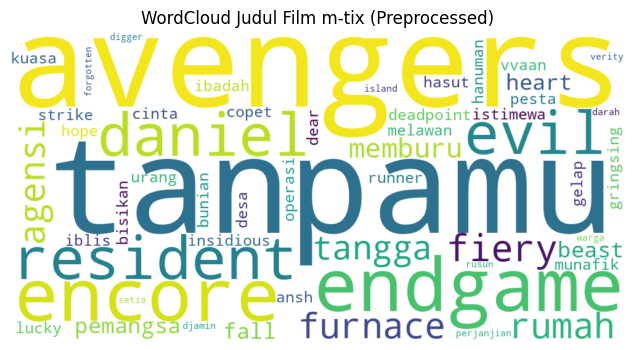

Exercise 4! File "hasil_exercise4_preprocessed.csv" telah disimpan.
 "hasil_exercise4_preprocessed.xlsx


In [23]:
# Generate WordCloud dari teks hasil preprocessing akhir
text_combined = ' '.join(df['rm_stopwords'].dropna().astype(str))
wordcloud = WordCloud(
    width=1000, height=500, background_color='white'
).generate(text_combined)

# Tampilkan Grafik WordCloud
plt.figure(figsize=(8, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Judul Film m-tix (Preprocessed)')
plt.show()

# Simpan hasil tugas Exercise 4 ke CSV dan EXCEL
df.to_csv('hasil_exercise4_preprocessed.csv', index=False, encoding='utf-8-sig')
print('Exercise 4! File "hasil_exercise4_preprocessed.csv" telah disimpan.')

df.to_excel('hasil_exercise4_preprocessed.xlsx', index=False)
print(' "hasil_exercise4_preprocessed.xlsx')